# Introduction à la transformée de Fourier

In [42]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Pourquoi s'intéresser à la transformée de Fourier?

Deux raisons (parmi 2000, elle est vraiment partout) :
- Analyse : pouvoir observer le spectre d'un signal
- Filtrage : pouvoir designer simplement des filtres d'égalisation

/Users/pyrus/.pyenv/versions/3.12.13/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pyrus/.pyenv/versions/3.12.13/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


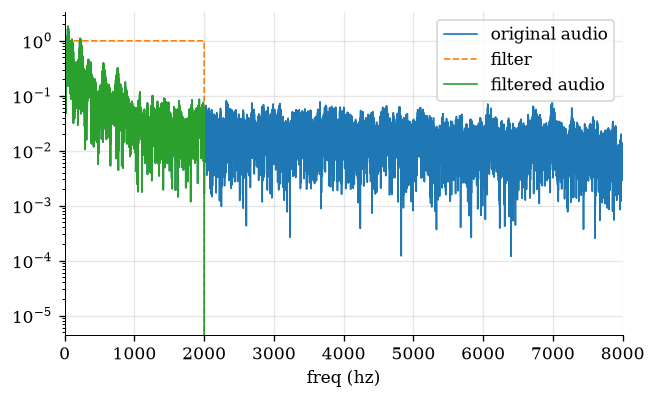

In [43]:
# read file
x, fs = wavread('assets/drums.wav')

# play sound
playsound(x, fs)

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# plot
plt.plot(freqs, np.abs(X) / np.max(X), label = 'original audio')

# create filter (gate) and apply
cutoff_freq = 2000
W = np.ones_like(freqs)
W[freqs > cutoff_freq] = 0

# plot
plt.plot(freqs, W, '--', label = 'filter');

# filter
X = np.multiply(X, W)

# plot
plt.plot(freqs, np.abs(X) / np.max(X), label = 'filtered audio')

# plot format
plt.yscale('log')
plt.xlim([0, 8000]); 
plt.xlabel('freq (hz)'); plt.legend(); plt.show()

# ifft
x = np.fft.irfft(X, n)

# play
playsound(x, fs)

## Tout n'est qu'oscillations

Les couleurs décomposées / reconstruites à partir d'une somme de valeurs RBG (red, green, blue).

De la même façon, les sons (plus précisément toute forme d'onde périodique) peuvent être **décomposés / reconstruits à partir d'une somme de sinus et cosinus** (merci Jean-Baptiste Joseph Fourier).

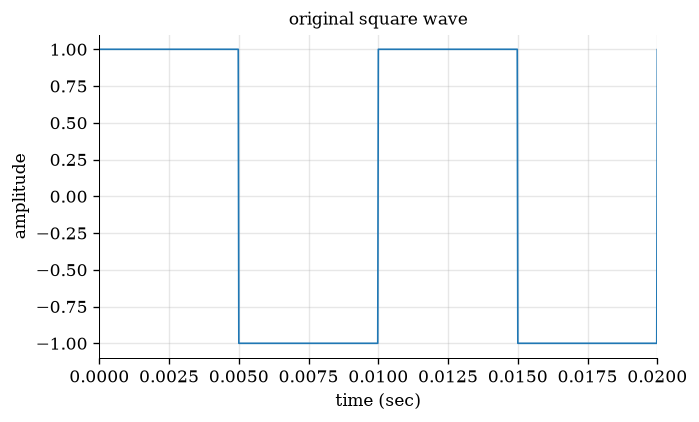

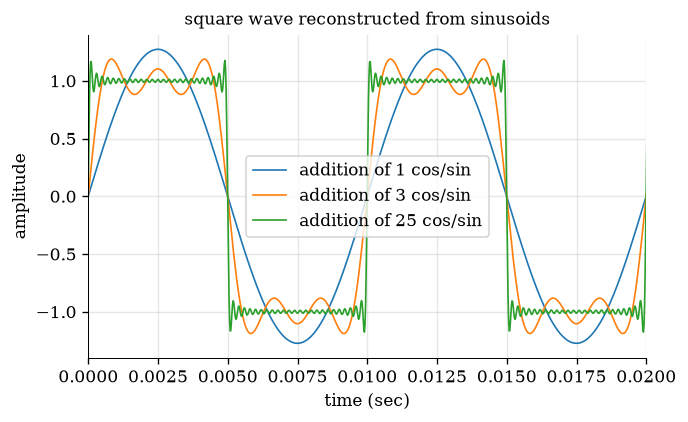

In [44]:
# define signal 
f1 = 100
duration_in_sec = 1
t = np.arange(0, duration_in_sec * fs)/fs
x = scipy.signal.square(2*math.pi*f1*t, duty = 0.5)

# plot
plt.plot(t, x);
plt.title('original square wave'); plt.xlabel('time (sec)'); plt.ylabel('amplitude')
plt.xlim([0, 0.02]); plt.show()

# decompose
n = len(x)
X = np.fft.rfft(x, n) / n
f = np.fft.rfftfreq(n, 1/fs)

# # plot
# plt.plot(f, np.abs(X));
# plt.xlim(0, 2000); plt.show();

# find peaks
peaks_ids, peaks_props = scipy.signal.find_peaks(np.abs(X), threshold = 0.01)

# loop over freq
# for i_freq in range(1, len(peaks_ids), 2):
for i_freq in [1, 3, 25]:

    # extract 
    Y = np.zeros_like(X)
    Y[peaks_ids[0:i_freq]] = X[peaks_ids[0:i_freq]]

    # plot
    # plt.plot(f, np.abs(Y))

    # back to time domain 
    y = np.fft.irfft(Y, n) * n
    
    # plot
    plt.plot(t, y, label = f'addition of {i_freq} cos/sin')

# format plot
plt.title('square wave reconstructed from sinusoids'); plt.xlabel('time (sec)'); plt.ylabel('amplitude')
plt.legend(); plt.xlim([0, 0.02]); plt.show()


## Une propriété intéressante

L'air sous la courbe de la multiplication de deux sinus est ~ nulle sauf s'ils oscillent à la même fréquence.

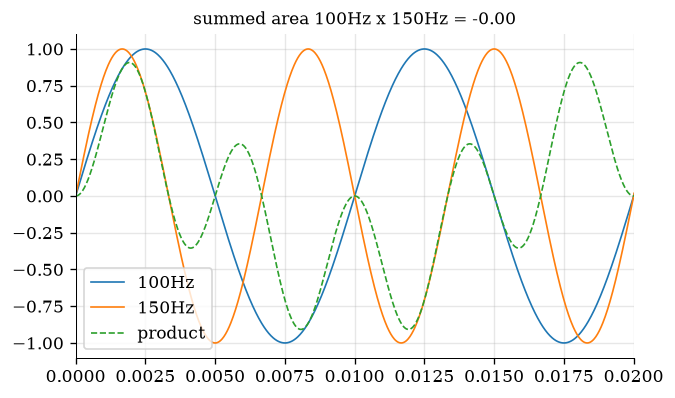

In [45]:
# define signals
f1 = 100; f2 = 150

# create signals
x1, t = get_sine(f1, sampling_rate = fs)
x2, t = get_sine(f2, sampling_rate = fs)

# area under multiplied curves
y = np.multiply(x1, x2)

# plot
plt.plot(t, x1, label = f'{f1}Hz')
plt.plot(t, x2, label = f'{f2}Hz')
plt.plot(t, y, '--', label = f'product')
plt.title(f'summed area {f1}Hz x {f2}Hz = {(np.sum(y) / len(y)):0.2f}')
plt.xlim([0, 0.02]); plt.legend();

Si on réalise cette opération (multiplication et calcul de l'air sous la courbe) sur un signal audio et que le résultat n'est pas nul, c'est que ce signal contenait de l'énergie à cette fréquence.

Si on répète cette opération avec des sinus dont les fréquences couvrent tout le spectre, e.g. [0Hz, 10Hz, 20Hz, ..., Fmax], les valeurs qu'on obtient représentent le spectre de $x(t)$ à ces fréquences.

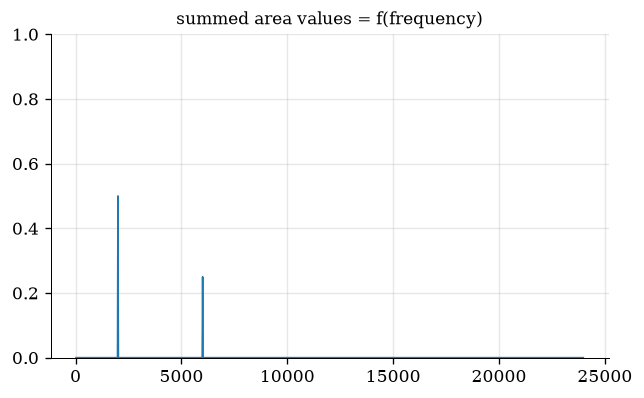

In [54]:
# init locals
f1 = 2000; f2 = 6000

# create audio input
x1, t = get_sine(f1, sampling_rate = fs)
x2, t = get_sine(f2, sampling_rate = fs)
y = 1*x1 + 0.5*x2

# multiply by sines and calculate area
coefs = []
freqs = np.arange(20, fs/2, 20)
for freq in freqs:
    sin, t = get_sine(freq, sampling_rate = fs)
    coef = np.sum( np.multiply(sin, y) ) / len(y)
    coefs.append(coef)

# plot
plt.plot(freqs, np.abs(coefs));
plt.ylim([0, 1]); plt.title('summed area values = f(frequency)')
plt.show()

## Un tamis plus fin pour ne rien rater

On a un léger problème : l'air sous la courbe de $x(t) * sin(2 \pi f_1 t)$ peut être nulle même si $x(t)$ a une composante qui oscille à $f_1$ si celle-ci est légèrement **déphasée**, i.e. $= sin(2 \pi f_1 t + \varphi)$.

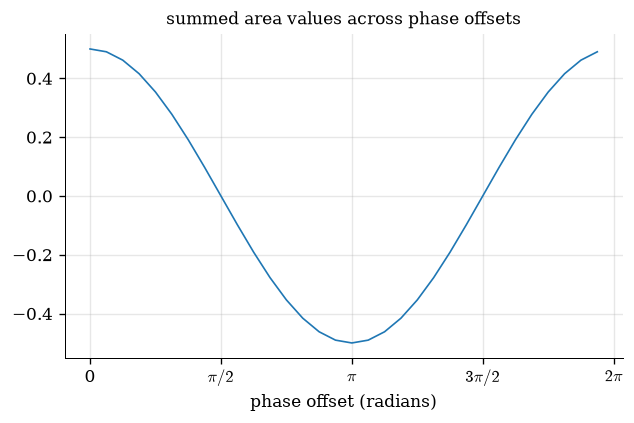

In [55]:
# init locals
phase_offsets = np.arange(0, 2*math.pi, math.pi/16)
f1 = 100; f2 = 100

# loop over phase signals
coefs = []
for phase in phase_offsets:
    x1, t = get_sine(f1, sampling_rate = fs)
    x2, t = get_sine(f2, sampling_rate = fs, phase = phase)
    coefs.append( np.sum( np.multiply(x1, x2) ) / len(x1) )

# area under multiplied curves
plt.plot(phase_offsets, coefs);
plt.xlabel('phase offset (radians)');
plt.xticks([0, math.pi/2, math.pi, 3*math.pi/2, 2*math.pi], ['0', '$\\pi /2$', '$\\pi$', '$3\\pi /2$', '$2\\pi$']);
plt.title('summed area values across phase offsets');

Pour s'assurer de détecter toutes les composantes fréquentielles, on multiplie donc $x(t)$ par $sin(2 \pi f_1 t)$ **et** $sin(2 \pi f_1 t + \pi / 2) = cos(2 \pi f_1 t)$. Cet ajustement permet de "couvrir" tous les cas de déphasage.

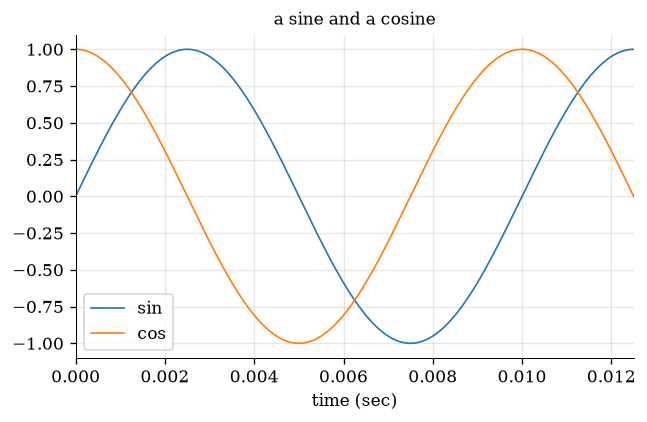

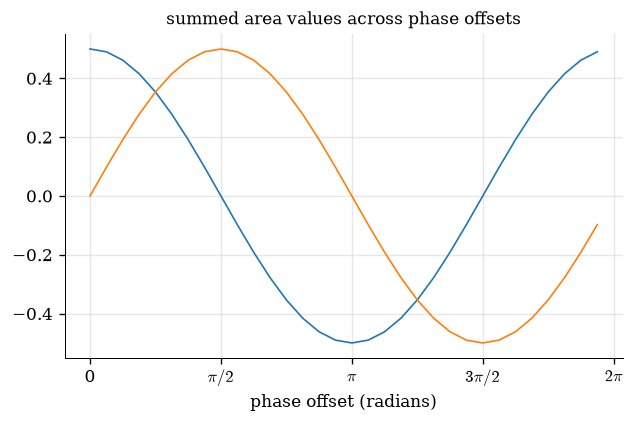

In [62]:
# create signal
freq = 100
sin, t = get_sine(freq, sampling_rate = fs)
cos, t = get_sine(freq, sampling_rate = fs, phase = math.pi/2)

# plot
plt.plot(t, sin, label = 'sin');
plt.plot(t, cos, label = 'cos');
plt.legend(); plt.xlim([0, 0.0125]);  
plt.xlabel('time (sec)'); plt.title('a sine and a cosine'); plt.show()

# init locals
phase_offsets = np.arange(0, 2*math.pi, math.pi/16)

# loop over phase signals
coefs_sin = []
coefs_cos = []
for phase in phase_offsets:
    x, t = get_sine(freq, sampling_rate = fs, phase = phase)
    coefs_sin.append( np.sum( np.multiply(x, sin) ) / len(x) )
    coefs_cos.append( np.sum( np.multiply(x, cos) ) / len(x) )

# area under multiplied curves
plt.plot(phase_offsets, coefs_sin, label = 'sin');
plt.plot(phase_offsets, coefs_cos, label = 'cos');
plt.xlabel('phase offset (radians)')
plt.xticks([0, math.pi/2, math.pi, 3*math.pi/2, 2*math.pi], ['0', '$\\pi /2$', '$\\pi$', '$3\\pi /2$', '$2\\pi$'])
plt.title('summed area values across phase offsets'); plt.show()

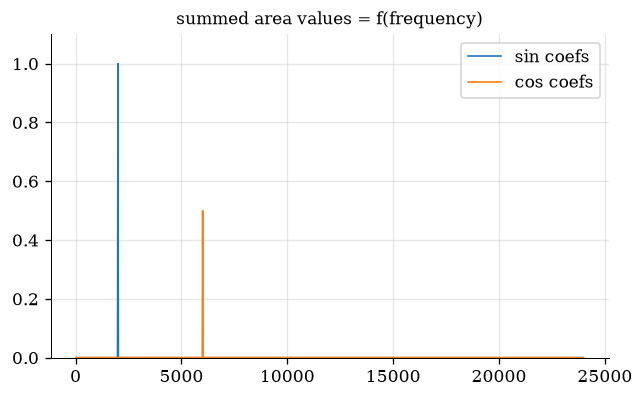

In [63]:
# init locals
x1, t = get_sine(2000, sampling_rate = fs)
x2, t = get_sine(6000, sampling_rate = fs, phase = math.pi/2)
y = 1*x1 + 0.5*x2

# local function
def fft(x, freqs):
    coefs = np.empty((len(freqs), 2))
    for i_freq in range(len(freqs)):
        freq = freqs[i_freq]
        sin, t = get_sine(freq, sampling_rate = fs)
        cos, t = get_sine(freq, sampling_rate = fs, phase = - math.pi/2)
        coefs[i_freq, 0] = np.sum( np.multiply(sin, x) ) / len(x)
        coefs[i_freq, 1] = np.sum( np.multiply(cos, x) ) / len(x)
    coefs *= 2
    return coefs

# project with both sin and cos
freqs = np.arange(20, fs/2, 20)
coefs = fft(y, freqs)

# plot
plt.plot(freqs, np.abs(coefs[:, 0]), label = 'sin coefs')
plt.plot(freqs, np.abs(coefs[:, 1]), label = 'cos coefs')
plt.ylim([0, 1.1]); plt.legend(); plt.title('summed area values = f(frequency)');

L'opération complete s'écrit : $\text{coef}_{sin, f} = \sum_{t=0}^{Tmax} x(t) * sin(2\pi ft)$. On remplace $sin$ par $cos$ pour calculer $\text{coef}_{cos, f}$.

## Revenir dans le domaine temporel

Pour récupérer le signal d'origine, il suffit de le reconstituer en additionnant des sinus et cosinus 1) oscillant à chacune des fréquences utilisées pour la décomposition [0Hz, 10Hz, 20Hz, ..., Fmax] et 2) avec un le gain obtenu pour chacune d'elle pendant la décomposition.

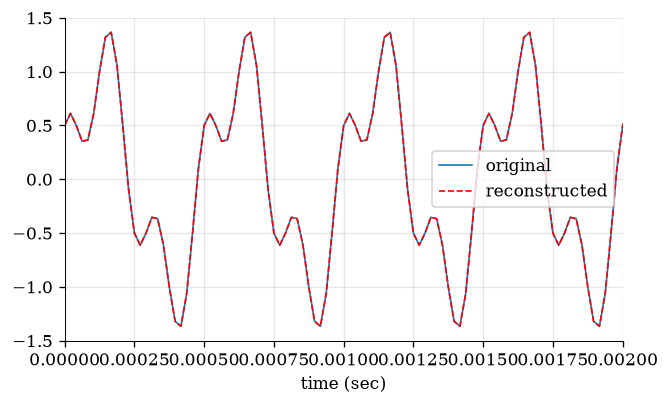

In [64]:
# manual reconstruction
def ifft(coefs, freqs):
    duration_in_sec = 1
    x = np.zeros(duration_in_sec * fs)
    for i_freq in range(len(freqs)):
        sin, t = get_sine(freqs[i_freq], sampling_rate = fs, duration_in_sec=duration_in_sec)
        cos, t = get_sine(freqs[i_freq], sampling_rate = fs, duration_in_sec=duration_in_sec, phase = - math.pi/2)
        x += coefs[i_freq, 0] * sin + coefs[i_freq, 1] * cos
    return x

# reconstruction
y2 = ifft(coefs, freqs)
t2 = np.arange(0, len(y2)) / fs

# plot
plt.plot(t, y, label = 'original')
plt.plot(t2, y2, '--r', label = 'reconstructed')
plt.xlim([0, 0.002]); plt.xlabel('time (sec)')
plt.legend(); plt.show()

Cette opération s'écrit : $x(t) = \sum_{f=0}^{Fmax} \big[ \text{coef}_{sin, f} * sin(2\pi ft) + \text{coef}_{cos, f} * cos(2\pi ft) \big]$.

## La transformée de Fourier

Pour simplifier la manipulation de cette paire de coefficients, on les stock dans un nombre complexe: $\text{coef}_{cos, f}$ dans sa partie réelle, $\text{coef}_{sin, f}$ dans sa partie imaginaire.

La première opération, l'extraction des coefficients représentant la présence des différentes fréquences du spectre, s'écrit alors $X(f) = \sum_{t=0}^{Tmax} x(t) . \big[ cos(2\pi ft) + j.sin(2\pi ft) \big]$.

Pour économiser du papier (et se simplifier la vie plus tard), les mathématiciens ont proposé les notations : $\omega = 2 \pi f$ et $e^{j \omega t} = cos(\omega t) + j.sin(\omega t)$.

L'opération, ou **transformée de Fourier discrete** pour lui donner son nom, s'écrit alors : $X(w) = \sum_{t=0}^{Tmax} x(t) . e^{-j \omega t}$.

L'opération inverse, la **transformée de Fourier inverse discrete** s'écrit $x(t) = \sum_{w=0}^{Wmax} X(\omega) . e^{j \omega t}$.

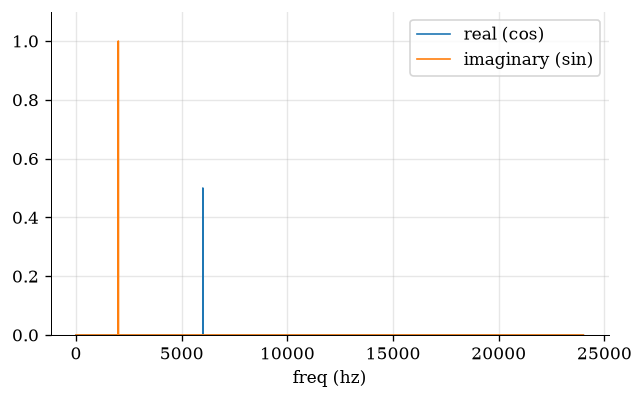

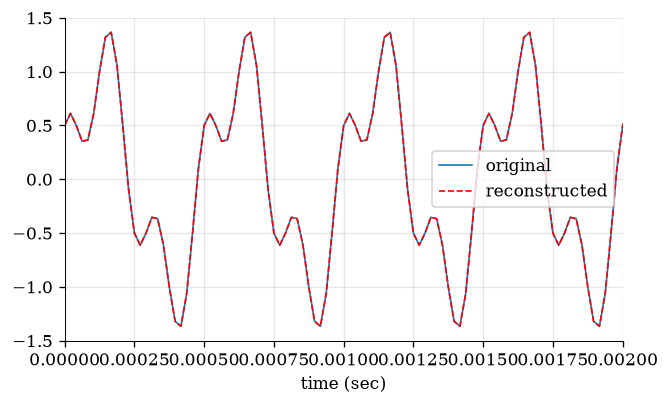

In [51]:
# fft
n = len(y)
coefs = np.fft.rfft(y, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# ifft
y2 = np.fft.irfft(coefs, n)

# plot
plt.plot(freqs, np.abs(np.real(coefs)) / len(coefs), label = 'real (cos)');
plt.plot(freqs, np.abs(np.imag(coefs)) / len(coefs), label = 'imaginary (sin)');
plt.xlabel('freq (hz)'); plt.legend(); plt.ylim([0, 1.1]); plt.show();
plt.plot(t, y, label = 'original')
plt.plot(t2, y2, '--r', label = 'reconstructed');
plt.xlim([0, 0.002]); plt.xlabel('time (sec)')
plt.legend(); plt.show()

## Exemple d'utilisation pour le filtrage

Exemple typique d'utilisation de la transformée de Fourier pour filtrer une partie du spectre non désirée.

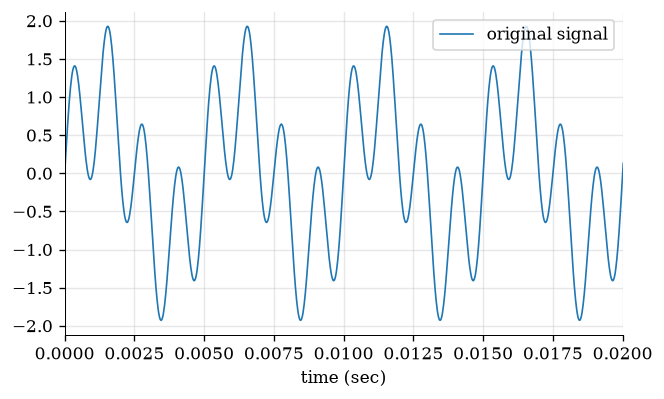

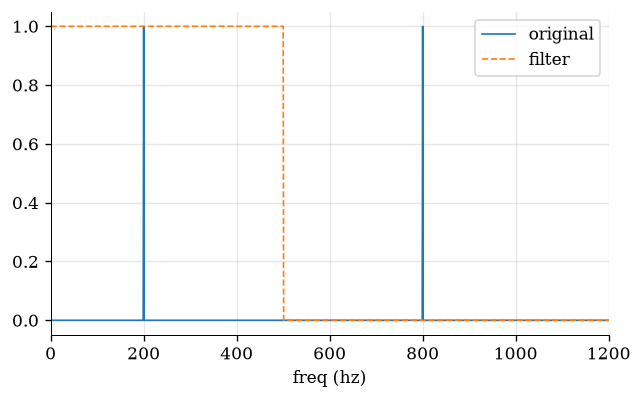

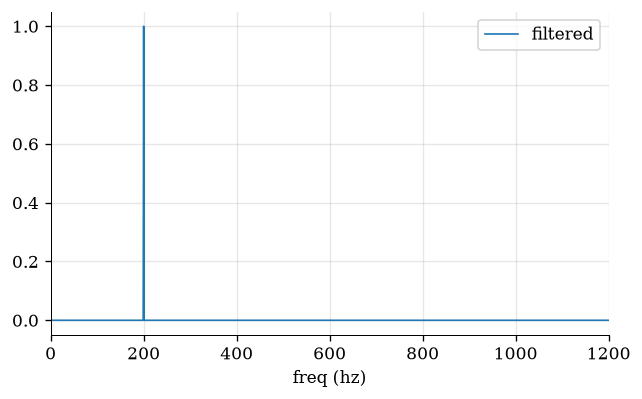

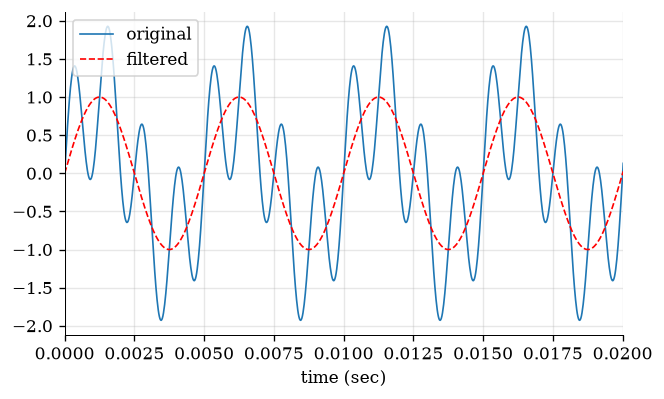

In [52]:
# init locals
f1 = 200
f2 = 800
cutoff_freq = 500

# define signals
x1, t = get_sine(f1, sampling_rate = fs)
x2, t = get_sine(f2, sampling_rate = fs)
x = x1 + x2

# play
playsound(x, fs)

# plot
plt.plot(t, x, label = 'original signal');
plt.legend(); plt.xlabel('time (sec)');
plt.xlim([0, 0.02]); plt.show();

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# create filter (gate) and apply
W = np.ones_like(freqs)
W[freqs > cutoff_freq] = 0
X_filtered = np.multiply(X, W)

# plot
plt.plot(freqs, np.abs(X) / len(X), label = 'original');
plt.plot(freqs, W, '--', label = 'filter');
plt.xlim([0, 1.5*max(f1, f2)]); plt.xlabel('freq (hz)'); plt.legend(); plt.show();

# plot
plt.plot(freqs, np.abs(X_filtered) / len(X_filtered), label = 'filtered')
plt.xlim([0, 1.5*max(f1, f2)]); plt.xlabel('freq (hz)'); plt.legend(); plt.show();

# ifft
x_filtered = np.fft.irfft(X_filtered, n)

# play
playsound(x_filtered, fs)

# plot
plt.plot(t, x, label = 'original')
plt.plot(t, x_filtered, '--r', label = 'filtered')
plt.xlim([0, 0.02]); plt.xlabel('time (sec)'); plt.legend(); plt.show()

## Resources additionnelles

- 3Blue1Brown video: [But what is the Fourier Transform? A visual introduction](https://www.youtube.com/watch?v=spUNpyF58BY)